In [1]:
import numpy as np
import matplotlib.pyplot as plt

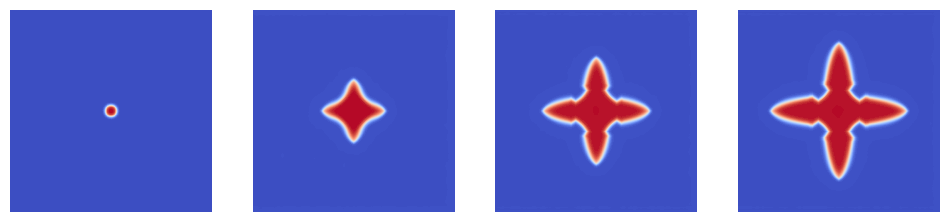

In [5]:
solutions = np.load("./data/train_valid/solutions_grid.npy")[1, :, 0, ...]
mesh = np.load("./data/train_valid/mesh_grid_coords.npy")
mesh = np.transpose(mesh, (2, 0, 1))
meshx = mesh[0, :, :]
meshy = mesh[1, :, :]
tics = [0, 60, 120, 160]

fig, axes = plt.subplots(1, len(tics), figsize=(12, 3))
axes = axes.flatten()
for i, tic in enumerate(tics):
    ax = axes[i]
    ax.contourf(meshx, meshy, solutions[tic, :, :], levels=100, cmap='coolwarm')
    ax.set_aspect('equal')
    ax.set_axis_off()

In [6]:
from configs.train_debug import Configs
configs = Configs()
mesh = np.load("./data/train_valid/mesh_grid_coords.npy")
mesh = np.transpose(mesh, (2, 0, 1))
meshx = mesh[0, :, :]
meshy = mesh[1, :, :]
times = np.load("./data/train_valid/times.npy")
dt = times[1] - times[0]
num_times = times.shape[0]
solutions = np.load("./data/train_valid/solutions_grid.npy")
num_ks = solutions.shape[0]
Xs = np.zeros(
    (num_ks * (num_times - 1), 5, 
     mesh.shape[1], mesh.shape[2])
) # 4: phi, T, meshx, meshy, k
Ys = np.zeros(
    (num_ks * (num_times - 1), 2, 
     mesh.shape[1], mesh.shape[2])
) # 2: phi, T
K_values = np.load("./data/train_valid/K_values.npy")
Ks = np.zeros((num_ks * (num_times - 1), 1))

for i in range(num_ks):
    Xs[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, :-1, 0, :, :]  # phi
    Xs[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, :-1, 1, :, :]  # T
    Xs[i*(num_times-1):(i+1)*(num_times-1), 3, :, :] = meshx / configs.Lc  # meshx
    Xs[i*(num_times-1):(i+1)*(num_times-1), 4, :, :] = meshy / configs.Lc  # meshy
    Xs[i*(num_times-1):(i+1)*(num_times-1), 2, :, :] = K_values[i]  # k

    Ys[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, 1:, 0, :, :]  # phi
    Ys[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, 1:, 1, :, :]  # T

    Ks[i*(num_times-1):(i+1)*(num_times-1), 0] = K_values[i]

In [7]:
K_values.shape

(4,)

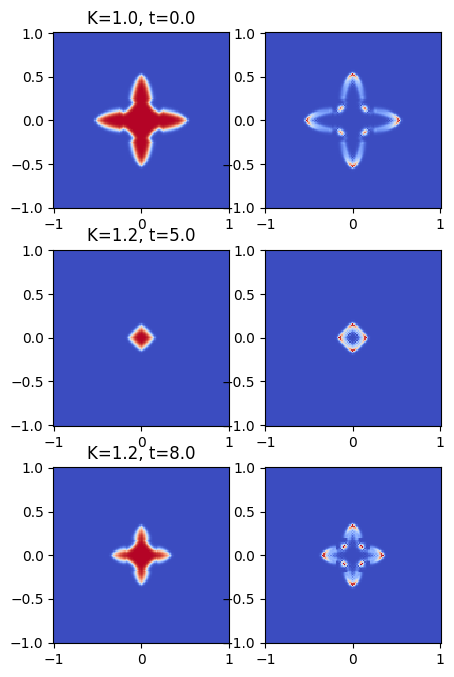

In [8]:
import matplotlib.pyplot as plt
ts = [0, 100, 159]
fig, axes = plt.subplots(3, 2, figsize=(5, 8))
for idx, t in enumerate(ts):
    t += 160*2
    x = Xs[t, 0, :, :]
    y = Ys[t, 0, :, :]
    meshx = Xs[t, 3, :, :] * configs.Lc
    meshy = Xs[t, 4, :, :] * configs.Lc
    ax = axes[idx, 0]
    im = ax.pcolormesh(meshx, meshy, x, cmap="coolwarm")
    ax.set_aspect('equal')
    k = Xs[t, 2, 0, 0]
    ax.set_title(f"K={k:.1f}, t={ts[idx] * dt:.1f}")

    ax = axes[idx, 1]
    diff = np.abs(y - x)
    im = ax.pcolormesh(meshx, meshy, diff, cmap="coolwarm")
    ax.set_aspect('equal')


In [9]:
# solutions[0, 100, 1, :, :].min(), solutions[0, 100, 1, :, :].max()
np.max(solutions[0, :, 1, :, :], axis=(1,2))

array([ 4.99600361e-17, -9.97099549e-03, -2.61758652e-02, -4.11926836e-02,
       -5.28197501e-02, -6.15186171e-02, -6.79927533e-02, -7.26968215e-02,
       -7.59737745e-02, -7.81023258e-02, -7.54835008e-02, -6.99089789e-02,
       -6.43357055e-02, -6.06603572e-02, -5.43501967e-02, -4.95922621e-02,
       -4.66065833e-02, -4.17258006e-02, -3.69927098e-02, -3.41424963e-02,
       -3.17246948e-02, -2.65339392e-02, -2.35033618e-02, -2.11891851e-02,
       -1.91542494e-02, -1.53294710e-02, -1.24138902e-02, -1.10083253e-02,
       -9.63587832e-03, -5.77769387e-03, -3.82507175e-03, -1.81556468e-03,
       -1.31888294e-03,  4.86380322e-04,  3.68650956e-03,  4.57964979e-03,
        6.33085471e-03,  6.22776932e-03,  7.89537977e-03,  1.11347421e-02,
        1.11405505e-02,  1.31779216e-02,  1.24848335e-02,  1.37643699e-02,
        1.68260946e-02,  1.60021011e-02,  1.86388643e-02,  1.73567225e-02,
        1.90865351e-02,  2.13178023e-02,  1.94864786e-02,  2.32691752e-02,
        2.12313083e-02,  

In [10]:
np.savez(
    "./data/train_valid/dataset_2d_complete.npz",
    meshes=mesh/configs.Lc,
    times=times/configs.Tc,
    Xs=Xs,
    Ys=Ys,
)

In [11]:
print(mesh[0])
print(mesh[1])

[[-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 ...
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]
 [-1.       -0.984375 -0.96875  ...  0.96875   0.984375  1.      ]]
[[-1.       -1.       -1.       ... -1.       -1.       -1.      ]
 [-0.984375 -0.984375 -0.984375 ... -0.984375 -0.984375 -0.984375]
 [-0.96875  -0.96875  -0.96875  ... -0.96875  -0.96875  -0.96875 ]
 ...
 [ 0.96875   0.96875   0.96875  ...  0.96875   0.96875   0.96875 ]
 [ 0.984375  0.984375  0.984375 ...  0.984375  0.984375  0.984375]
 [ 1.        1.        1.       ...  1.        1.        1.      ]]


In [12]:
K_values

array([0.8, 1. , 1.2, 1.4])